# 손 X-ray 골연령 — **ConvNeXt-Tiny 단일 회귀 / 전처리 없음 (레터박스 512만)**

Attention·LDL 없이 **단일 모델**로 돌리는 베이스라인입니다.
화소값을 바꾸는 전처리(정규화·Top-Hat·CLAHE·마커억제·회전정렬)는 **전부 제거**했고,
네트워크 입력 크기를 맞추기 위한 **기하 변환만** 남겼습니다.

```
crop_data 원본 → [uint8 보장] → 비율유지 리사이즈 → 0 패딩 → 512×512
```

## 백본 — 상업 사용 가능한 ConvNeXt

| 모델 | 계열 | 라이선스 | 상업 |
|---|---|---|---|
| **`convnext_tiny.fb_in22k_ft_in1k_384`** ← 기본값 | V1 | Apache-2.0 / MIT | 가능 |
| `convnext_tiny.fb_in22k_ft_in1k` | V1 | Apache-2.0 / MIT | 가능 |
| `convnext_tiny.in12k_ft_in1k` | V1 (timm 자체) | Apache-2.0 | 가능 |
| ~~`convnextv2_*`~~ | V2 | **CC BY-NC 4.0** | **불가** |

ConvNeXt V2 저장소는 코드가 MIT지만 ImageNet 사전학습·미세조정 **가중치는 CC BY-NC**입니다.
timm `convnext.py` 주석에도 상업 사용 주의가 명시돼 있어 이 노트북에서는 V1만 씁니다.
`_384` 가중치를 고른 이유는 **384 해상도로 미세조정된 특징**이라 512 입력에서 스케일 미스매치가 가장 작기 때문입니다.

## 하이퍼파라미터 개선 포인트

| 항목 | 값 | 근거 |
|---|---|---|
| AdamW + norm/bias `wd=0` | wd 0.05 | ConvNeXt 원 레시피. LayerNorm에 wd를 주면 손해 |
| 차등 LR | backbone 1e-5 / head 1e-4 | 사전학습 특징 보존 |
| warmup 3ep + cosine | min ratio 0.02 | plateau 스케줄보다 반응이 빠름 |
| drop_path | 0.1 | ConvNeXt 전용 stochastic depth |
| EMA | decay 0.999 | 회귀에서 가장 확실한 무료 개선 |
| grad accumulation | 8 × 4 = 유효 32 | 8GB VRAM에서 큰 배치 효과 |
| Huber | beta 0.5 (z-scale) | 극단 연령 이상치 완화 |

## 실행 순서
`PART 0` → `PART 1`(캐시 1회) → `PART 2` → `PART 3`(학습) → `PART 4`(평가)
`PART 4`는 `best.pt`만 있으면 단독 실행됩니다.


---
# PART 0 · 공통 셋업  *(전부 정의/로드 — 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time, copy
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from tqdm.auto import tqdm

# !pip install timm            # 최초 1회만
import timm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("timm       :", timm.__version__)
print("OpenCV     :", cv2.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# RTX 5060(Blackwell, sm_120)에서 CUDA=False 또는 'no kernel image' 오류가 나면:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
timm       : 1.0.28
OpenCV     : 4.10.0
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더
`cv2.imread/imwrite`는 경로에 한글이 있으면 **조용히 실패**합니다 → `np.fromfile + imdecode` 조합을 씁니다.

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        return cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), flags)
    except Exception:
        return None


def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    try:
        ok, buf = cv2.imencode(ext, img)
        if ok:
            buf.tofile(path)
        return ok
    except Exception:
        return False


def torch_load(path, map_location=None):
    '''PyTorch 2.6+ 는 weights_only 기본값이 True -> arch 딕셔너리 로드가 막힙니다.'''
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def require(path, what):
    '''경로가 없으면 즉시 중단. 잘못된 경로로 조용히 진행하지 않습니다.'''
    p = Path(path)
    assert p.exists(), f"[중단] {what} 경로가 없습니다: {p}"
    return p

print("헬퍼 정의 완료 · SEED =", SEED)

헬퍼 정의 완료 · SEED = 42


### 0-3. 경로 & 이미지 준비 설정
**`BASE_DIR` 한 줄만** 본인 환경에 맞게 수정하세요.
캐시/체크포인트 폴더는 v8·v10 실험과 **완전히 분리**되어 있습니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR      = Path(r"C:\Users\Win11Pro\Desktop")
HAND_CROP_DIR = BASE_DIR / "crop_data"        # training / validation / test 하위폴더
CSV_DIR       = BASE_DIR / "crop_data_csv"    # training.csv / validation.csv / test.csv

SPLIT_SUBDIR = {"train": "training", "val": "validation", "test": "test"}

TRAIN_CSV = require(CSV_DIR / "training.csv",   "training.csv")
VAL_CSV   = require(CSV_DIR / "validation.csv", "validation.csv")
TEST_CSV  = require(CSV_DIR / "test.csv",       "test.csv")
require(HAND_CROP_DIR, "손 크롭 폴더")

# ══ 이미지 준비 = 기하 변환만 (화소값 조작 없음) ═══════════════════════
IMG_SIZE    = 512          # 최종 정사각 캔버스
RESIZE_MODE = "letterbox"  # "letterbox"(비율유지+패딩, 권장) | "stretch"(정사각 강제)
PAD_VALUE   = 0            # 배경색 추정 제거 -> 상수 0
PAD_ANCHOR  = "center"     # "center" | "topleft"

# 설정이 다르면 캐시 폴더가 자동으로 분리됩니다
PRE_TAG   = f"raw{IMG_SIZE}_{RESIZE_MODE}_pad{PAD_VALUE}_{PAD_ANCHOR}"
CACHE_DIR = BASE_DIR / "cache_convnext_single" / PRE_TAG
CKPT_DIR  = BASE_DIR / "checkpoints_convnext_single"
for sp in SPLIT_SUBDIR:
    (CACHE_DIR / sp).mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRE_DONE     = CACHE_DIR / "_DONE.json"
BEST_CKPT    = CKPT_DIR / "best.pt"
LAST_CKPT    = CKPT_DIR / "last.pt"
HISTORY_JSON = CKPT_DIR / "history.json"
RESULTS_JSON = CKPT_DIR / "results.json"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"캐시   {CACHE_DIR}")
print(f"체크포인트 {CKPT_DIR}")
print(f"이미지 준비: 전처리 없음 | {RESIZE_MODE} -> {IMG_SIZE}px | pad {PAD_VALUE}")

캐시   C:\Users\Win11Pro\Desktop\cache_convnext_single\raw512_letterbox_pad0_center
체크포인트 C:\Users\Win11Pro\Desktop\checkpoints_convnext_single
이미지 준비: 전처리 없음 | letterbox -> 512px | pad 0


### 0-4. 제외 ID (v8/v10과 동일한 목록)
`USE_EXCLUDE=True`는 v8/v10과 **같은 조건**으로 비교하기 위한 설정입니다.
test에 필터를 적용하면 낙관적 편향이 생기므로, PART 4에서 **필터/비필터 두 수치를 모두** 출력합니다.

In [4]:
USE_EXCLUDE = True   # v8/v10 과 동일 조건으로 맞추려면 True

EXCLUDE_IDS = {} if USE_EXCLUDE else set()

print(f"제외 ID {len(EXCLUDE_IDS)}개 · USE_EXCLUDE={USE_EXCLUDE}")

제외 ID 0개 · USE_EXCLUDE=True


### 0-5. 라벨 로드 & 파일 인덱싱

In [5]:
def load_labels(csv_path):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}

    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc:
                    return orig
        return None

    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"

    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png", "", regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true": 1, "false": 0, "m": 1, "f": 0,
                       "male": 1, "female": 0, "1": 1, "0": 0})
        if male.isna().any():
            male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    return out.dropna(subset=["boneage", "male"]).reset_index(drop=True)


def index_files(split):
    '''{id(stem): 파일경로} 인덱스. 하위 폴더까지 재귀 탐색.'''
    d = HAND_CROP_DIR / SPLIT_SUBDIR[split]
    assert d.exists(), f"[중단] {split} 이미지 폴더 없음: {d}"
    idx = {}
    for ext in ("*.png", "*.PNG", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
        for p in d.rglob(ext):
            idx.setdefault(p.stem.strip(), p)
    return idx


SPLIT_DFS, FILE_INDEX = {}, {}
for sp, csv in [("train", TRAIN_CSV), ("val", VAL_CSV), ("test", TEST_CSV)]:
    df  = load_labels(csv)
    idx = index_files(sp)
    FILE_INDEX[sp] = idx
    before = len(df)
    if EXCLUDE_IDS:
        df = df[~df["id"].isin(EXCLUDE_IDS)]
    # 크롭 파일이 실제로 존재하는 행만 사용 (크롭 실패분 자동 제외)
    df = df[df["id"].isin(idx.keys())].reset_index(drop=True)
    df["path"] = df["id"].map(lambda i: str(idx[i]))
    SPLIT_DFS[sp] = df
    print(f"  {sp:<5} 라벨 {before:>6,} -> 사용 {len(df):>6,}  (제외/미크롭 {before-len(df):,})")

train_df, val_df, test_df = SPLIT_DFS["train"], SPLIT_DFS["val"], SPLIT_DFS["test"]
assert len(train_df) > 0, "[중단] train 사용 가능 이미지가 0장입니다."

# 타깃 z-정규화 상수는 반드시 train 에서만 (val/test 누수 방지)
AGE_MEAN = float(train_df["boneage"].mean())
AGE_STD  = float(train_df["boneage"].std())
print(f"\n타깃 정규화 (train 기준): {AGE_MEAN:.2f} ± {AGE_STD:.2f} 개월")
print(f"남아 비율 {train_df.male.mean():.1%} | 연령 범위 "
      f"{train_df.boneage.min():.0f}~{train_df.boneage.max():.0f} 개월")

  train 라벨 11,643 -> 사용 11,643  (제외/미크롭 0)
  val   라벨  1,324 -> 사용  1,324  (제외/미크롭 0)
  test  라벨    167 -> 사용    167  (제외/미크롭 0)

타깃 정규화 (train 기준): 128.45 ± 39.54 개월
남아 비율 54.5% | 연령 범위 4~228 개월


### 0-6. 이미지 준비 함수 — 화소값을 바꾸는 코드는 **여기에 없습니다**

| 함수 | 하는 일 |
|---|---|
| `to_gray8` | 16bit/float 입력만 8bit로 낮춤. **이미 uint8이면 무연산 통과** |
| `fit_canvas` | 비율유지 리사이즈 + 0 패딩 (또는 stretch) |

In [6]:
def to_gray8(g):
    '''16bit·float 입력만 8bit 로 변환.
       입력이 이미 uint8 이면 아무 연산도 하지 않고 그대로 반환합니다.'''
    if g.dtype == np.uint8:
        return g
    g = g.astype(np.float32)
    lo, hi = float(g.min()), float(g.max())
    if hi - lo < 1e-6:
        return np.zeros(g.shape, np.uint8)
    return np.clip((g - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)


def fit_canvas(g, size=IMG_SIZE, mode=RESIZE_MODE, pad_val=PAD_VALUE, anchor=PAD_ANCHOR):
    '''size x size 캔버스로 맞춥니다. 화소값 보정 없음. 반환 (canvas, info)'''
    g = to_gray8(g)
    h, w = g.shape[:2]

    if mode == "stretch":
        interp = cv2.INTER_AREA if (size < h and size < w) else cv2.INTER_CUBIC
        out = cv2.resize(g, (size, size), interpolation=interp)
        return out, {"sx": size / w, "sy": size / h, "src": (h, w),
                     "pad": (0, 0, 0, 0), "pad_frac": 0.0}

    # letterbox: 긴 변을 size 에 맞춤 -> 비율 왜곡 0
    s  = size / float(max(h, w))
    nh = max(1, min(size, int(round(h * s))))
    nw = max(1, min(size, int(round(w * s))))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC
    r = cv2.resize(g, (nw, nh), interpolation=interp)

    top  = 0 if anchor == "topleft" else (size - nh) // 2
    left = 0 if anchor == "topleft" else (size - nw) // 2
    out = cv2.copyMakeBorder(r, top, size - nh - top, left, size - nw - left,
                             cv2.BORDER_CONSTANT, value=int(pad_val))
    return out, {"sx": s, "sy": s, "src": (h, w),
                 "pad": (top, size - nh - top, left, size - nw - left),
                 "pad_frac": 1.0 - (nh * nw) / float(size * size)}

print("이미지 준비 함수 정의 완료 (전처리 단계 0개)")

이미지 준비 함수 정의 완료 (전처리 단계 0개)


---
# PART 1 · 캐시 생성  *(1회만; 완료 표식 있으면 자동 스킵)*
전처리가 없으므로 매우 빠릅니다. 12,611장 기준 수 분 내외.

In [7]:
FORCE_REBUILD = False   # 캐시를 강제로 다시 만들려면 True

PRE_INFO = {"preprocess": "none", "img_size": IMG_SIZE, "resize_mode": RESIZE_MODE,
            "pad_value": PAD_VALUE, "pad_anchor": PAD_ANCHOR,
            "n": {k: len(v) for k, v in SPLIT_DFS.items()}}


def cache_valid():
    if FORCE_REBUILD or not PRE_DONE.exists():
        return False
    try:
        return json.load(open(PRE_DONE, encoding="utf-8")) == PRE_INFO
    except Exception:
        return False


if cache_valid():
    print("캐시 유효 - PART 1 스킵 (다시 만들려면 FORCE_REBUILD=True)")
else:
    pad_fracs = []
    for sp in ("train", "val", "test"):
        df = SPLIT_DFS[sp]
        if not len(df):
            continue
        made = skipped = failed = 0
        for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache {sp}"):
            dst = CACHE_DIR / sp / f"{r['id']}.png"
            if dst.exists() and not FORCE_REBUILD:
                skipped += 1
                continue
            g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
            if g is None:
                failed += 1
                continue
            canvas, info = fit_canvas(g)
            imwrite_kr(dst, canvas)
            pad_fracs.append(info["pad_frac"])
            made += 1
        print(f"  [{sp}] 생성 {made:,} · 스킵 {skipped:,} · 실패 {failed:,}")
    if pad_fracs:
        pf = np.array(pad_fracs)
        print(f"\n여백 비율: 중앙 {np.median(pf):.1%} · 90%tile {np.percentile(pf,90):.1%} "
              f"· 최대 {pf.max():.1%}")
        if np.percentile(pf, 90) > 0.45:
            print("  [경고] 여백이 큽니다 -> 손 유효 해상도 손실. YOLO 크롭 마진을 점검하세요.")
    json.dump(PRE_INFO, open(PRE_DONE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    print("\n캐시 완료:", PRE_DONE)

캐시 유효 - PART 1 스킵 (다시 만들려면 FORCE_REBUILD=True)


### (필수) QC — 원본과 캔버스가 **화소값 기준으로 동일한지** 확인
전처리를 뺐다고 말하려면 실제로 뺐는지 증명해야 합니다.
아래 표에서 `원본std`와 `유효std`(패딩 제외 영역)가 **거의 같아야** 정상입니다.
차이가 크면 어딘가에서 화소값이 건드려지고 있다는 뜻입니다.

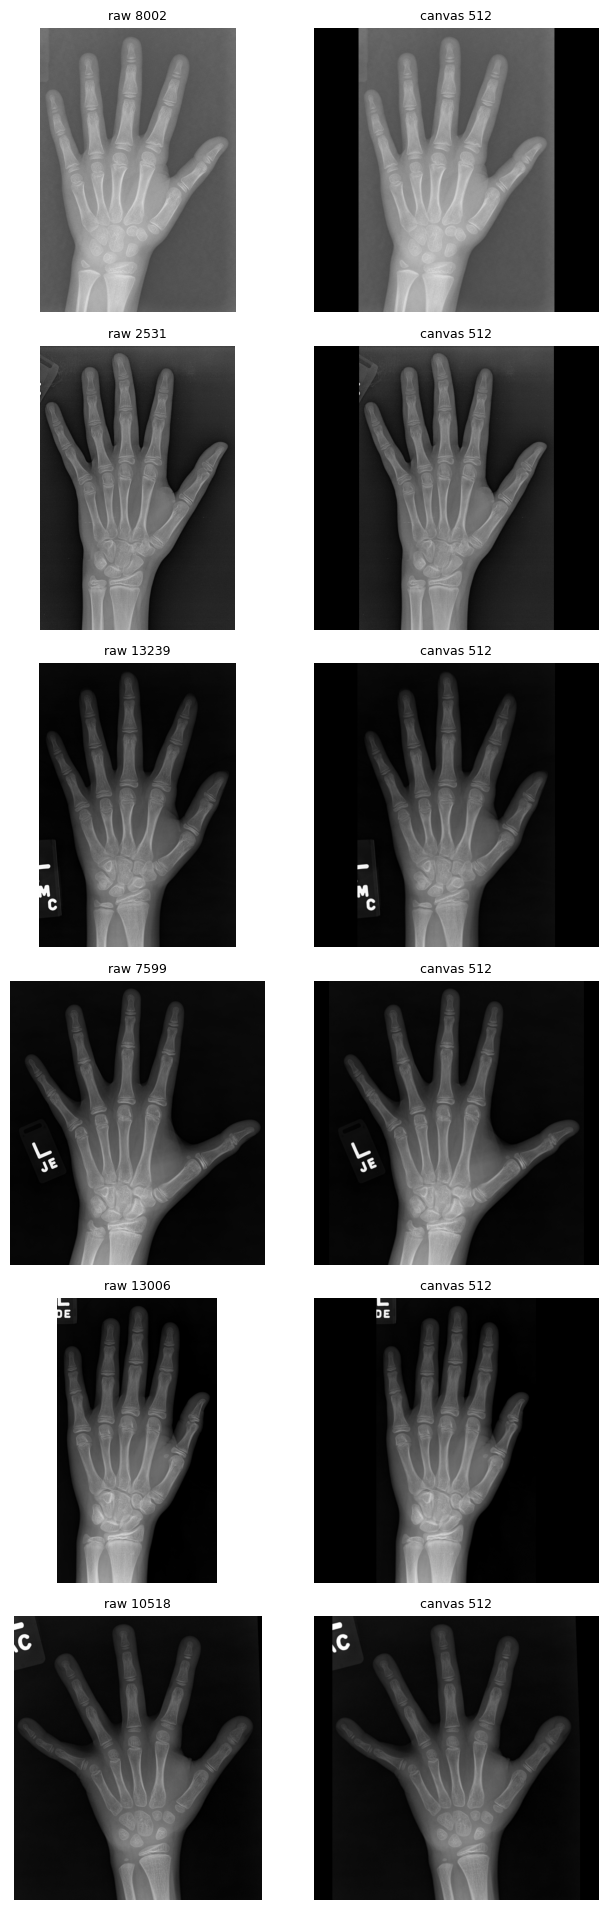

,id,원본크기,원본min~max,원본std,유효std,여백%,std비
0,8002,800x1165,65~232,36.8,36.6,31%,0.995
1,2531,1649x2413,0~255,42.6,42.3,32%,0.993
2,13239,960x1385,0~255,47.2,47.1,31%,0.998
3,7599,1438x1607,0~255,49.4,49.2,11%,0.996
4,13006,922x1642,0~255,56.4,56.3,44%,0.998
5,10518,1018x1171,0~255,40.9,40.8,13%,0.998


std비가 0.95~1.05 밖이면 리샘플링 외의 화소 조작이 끼어든 것입니다 (보간에 의한 미세 차이는 정상).


In [8]:
N_QC = 6
sample = train_df.sample(min(N_QC, len(train_df)), random_state=SEED)

fig, axes = plt.subplots(len(sample), 2, figsize=(7, 3.2 * len(sample)))
axes = np.atleast_2d(axes)
rows = []
for i, (_, r) in enumerate(sample.iterrows()):
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    cv_ = imread_kr(CACHE_DIR / "train" / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    _, info = fit_canvas(raw)
    top, bot, left, right = info["pad"]
    eff = cv_[top:cv_.shape[0]-bot if bot else None,
              left:cv_.shape[1]-right if right else None]  # 패딩 제외 유효 영역
    rows.append({"id": r["id"], "원본크기": f"{raw.shape[1]}x{raw.shape[0]}",
                 "원본min~max": f"{raw.min()}~{raw.max()}",
                 "원본std": round(float(raw.std()), 1),
                 "유효std": round(float(eff.std()), 1),
                 "여백%": f"{info['pad_frac']:.0%}"})
    for ax, (t, im) in zip(axes[i], [(f"raw {r['id']}", raw), (f"canvas {IMG_SIZE}", cv_)]):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(t, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

qc = pd.DataFrame(rows)
qc["std비"] = (qc["유효std"] / qc["원본std"]).round(3)
display(qc)
print("std비가 0.95~1.05 밖이면 리샘플링 외의 화소 조작이 끼어든 것입니다 (보간에 의한 미세 차이는 정상).")

---
# PART 2 · 학습 설정 ⚙️  *(여기서 하이퍼파라미터를 바꾸고 아래로 재실행)*

### 2-1. 하이퍼파라미터

`BACKBONE` 후보는 전부 상업 사용 가능한 ConvNeXt **V1** 계열입니다.
`convnextv2_*`는 가중치가 CC BY-NC 4.0이라 넣지 않았습니다.

In [9]:
# ── 백본 (상업 사용 가능한 V1 계열만) ───────────────────────────────
BACKBONE      = "convnext_tiny.fb_in22k_ft_in1k_384"
BACKBONE_ALT  = ["convnext_tiny.fb_in22k_ft_in1k",   # 224 ft. 가중치 (v8과 동일)
                 "convnext_tiny.in12k_ft_in1k"]      # timm 자체 학습 (Apache-2.0)
DROP_PATH     = 0.1        # ConvNeXt stochastic depth. 과적합 시 0.2까지

# ── 헤드 ───────────────────────────────────────────────────────────
HEAD_TYPE      = "gap"     # "gap"(권장) | "paper"(Conv3x3+MaxPool+Flatten, Xception 노트북 방식)
HEAD_DIM       = 512       # gap 헤드 은닉 폭
GENDER_EMB_DIM = 32
DROPOUT        = 0.2

# ── 최적화 ─────────────────────────────────────────────────────────
BATCH_SIZE   = 8           # 512px + 8GB VRAM 기준. OOM 이면 4
ACCUM_STEPS  = 4           # 유효 배치 = BATCH_SIZE * ACCUM_STEPS = 32
EPOCHS       = 100
LR_HEAD      = 1e-4
LR_BACKBONE  = 1e-5        # 사전학습 특징 보존 -> 헤드의 1/10
WEIGHT_DECAY = 0.05        # AdamW. norm/bias 에는 적용하지 않음
WARMUP_EPOCHS= 3
MIN_LR_RATIO = 0.02        # cosine 최저 LR = base * 이 값
CLIP_GRAD    = 1.0         # None 이면 끔

# ── 손실 ───────────────────────────────────────────────────────────
LOSS_TYPE  = "huber"       # "huber" | "l1"
HUBER_BETA = 0.5           # z-정규화 스케일 기준 (0.5*AGE_STD 개월 ≈ 전환점)

# ── 정칙화 / 증강 ──────────────────────────────────────────────────
USE_AUG       = True
AUG_ROT_DEG   = 12
AUG_TRANSLATE = 0.06
AUG_SCALE     = (0.92, 1.08)

# ── EMA ────────────────────────────────────────────────────────────
USE_EMA   = True
EMA_DECAY = 0.999

# ── 실행 ───────────────────────────────────────────────────────────
NUM_WORKERS = 0            # Windows + Jupyter 안전값
USE_AMP     = True
RESUME      = False
EARLY_STOP_PATIENCE = 12
MIN_DELTA           = 0.01
MIN_EPOCHS          = 20   # warmup+초반 변동 구간은 조기종료 판단에서 제외

ARCH = {"BACKBONE": BACKBONE, "IMG_SIZE": IMG_SIZE, "HEAD_TYPE": HEAD_TYPE,
        "HEAD_DIM": HEAD_DIM, "GENDER_EMB_DIM": GENDER_EMB_DIM, "DROPOUT": DROPOUT,
        "DROP_PATH": DROP_PATH, "PREPROCESS": "none",
        "RESIZE_MODE": RESIZE_MODE, "PAD_VALUE": PAD_VALUE, "PAD_ANCHOR": PAD_ANCHOR,
        "USE_AUG": USE_AUG, "USE_EXCLUDE": USE_EXCLUDE}

print(json.dumps(ARCH, ensure_ascii=False, indent=2))
print(f"\n유효 배치 = {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}")

{
  "BACKBONE": "convnext_tiny.fb_in22k_ft_in1k_384",
  "IMG_SIZE": 512,
  "HEAD_TYPE": "gap",
  "HEAD_DIM": 512,
  "GENDER_EMB_DIM": 32,
  "DROPOUT": 0.2,
  "DROP_PATH": 0.1,
  "PREPROCESS": "none",
  "RESIZE_MODE": "letterbox",
  "PAD_VALUE": 0,
  "PAD_ANCHOR": "center",
  "USE_AUG": true,
  "USE_EXCLUDE": true
}

유효 배치 = 8 x 4 = 32


### 2-2. Dataset · Transform

In [10]:
_aug = [transforms.RandomAffine(degrees=AUG_ROT_DEG,
                                translate=(AUG_TRANSLATE, AUG_TRANSLATE),
                                scale=AUG_SCALE, fill=PAD_VALUE)]

train_tf = transforms.Compose(
    [transforms.ToPILImage()] + (_aug if USE_AUG else []) +
    [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
)
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# 좌우 반전은 넣지 않습니다 - RSNA 는 전부 좌수 촬영이라 반전은 해부학적으로 없는 입력입니다.


class BoneAgeDataset(Dataset):
    '''캐시된 512 캔버스를 읽어 3채널 복제 -> 증강 -> ImageNet 정규화.'''
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR / self.split / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        if g is None:
            raise FileNotFoundError(f"캐시 없음: {self.split}/{r['id']}.png — PART 1을 먼저 실행하세요.")
        if g.shape[:2] != (IMG_SIZE, IMG_SIZE):
            g, _ = fit_canvas(g)
        x  = self.tf(np.stack([g] * 3, axis=-1))          # (3,H,W)
        gd = torch.tensor([float(r["male"])], dtype=torch.float32)
        ym = torch.tensor([float(r["boneage"])], dtype=torch.float32)
        yn = (ym - AGE_MEAN) / AGE_STD                    # z-정규화 타깃
        return x, gd, yn, ym


print("증강:", "ON" if USE_AUG else "OFF",
      f"(rot {AUG_ROT_DEG}도 / translate {AUG_TRANSLATE} / scale {AUG_SCALE})" if USE_AUG else "")

증강: ON (rot 12도 / translate 0.06 / scale (0.92, 1.08))


### 2-3. 모델 — ConvNeXt-Tiny + 성별 임베딩

- `HEAD_TYPE="gap"` : GAP → LayerNorm → Dense(512) → 성별 concat → Dense(128) → 1  *(권장)*
- `HEAD_TYPE="paper"` : Conv3x3(256) → MaxPool3x3 → Flatten → 성별 concat → 1  *(Xception 노트북과 동일 구조)*

512 입력에서 ConvNeXt-Tiny의 최종 특징맵은 16×16×768입니다.
`paper` 헤드는 flatten 차원이 커서 파라미터가 급증하므로, 데이터가 1.2만 장 규모인 지금은 `gap`이 유리합니다.

In [11]:
def make_backbone(name=None, pretrained=True, drop_path=None):
    '''상업 사용 가능한 ConvNeXt V1 백본 생성. 실패 시 대체 후보로 폴백.'''
    name      = BACKBONE   if name      is None else name
    drop_path = DROP_PATH  if drop_path is None else drop_path
    last_err = None
    for cand in [name] + [c for c in BACKBONE_ALT if c != name]:
        assert "convnextv2" not in cand, \
            f"[중단] {cand} 는 CC BY-NC 4.0 가중치입니다 (상업 사용 불가)."
        try:
            m = timm.create_model(cand, pretrained=pretrained, num_classes=0,
                                  global_pool="", drop_path_rate=drop_path)
            if cand != name:
                print(f"[backbone] '{name}' 실패 -> '{cand}' 로 폴백")
            print(f"[backbone] {cand} 로드 완료 (pretrained={pretrained}, drop_path={drop_path})")
            return m, cand
        except Exception as e:
            last_err = e
    raise RuntimeError(f"백본 생성 실패: {last_err}")


class ConvNeXtRegressor(nn.Module):
    def __init__(self, backbone_name=BACKBONE, img_size=IMG_SIZE, head_type=HEAD_TYPE,
                 head_dim=HEAD_DIM, gender_dim=GENDER_EMB_DIM, dropout=DROPOUT,
                 drop_path=DROP_PATH, pretrained=True):
        super().__init__()
        self.backbone, self.backbone_name = make_backbone(backbone_name, pretrained, drop_path)
        self.head_type = head_type

        with torch.no_grad():
            feat = self.backbone(torch.zeros(1, 3, img_size, img_size))
        C, H, W = feat.shape[1], feat.shape[2], feat.shape[3]
        print(f"[head] 특징맵 {tuple(feat.shape[1:])} · head_type={head_type}")

        if head_type == "gap":
            self.norm  = nn.LayerNorm(C)
            self.proj  = nn.Sequential(nn.Linear(C, head_dim), nn.GELU(), nn.Dropout(dropout))
            img_out = head_dim
        elif head_type == "paper":
            self.conv  = nn.Conv2d(C, 256, 3, padding=1)
            self.pool  = nn.MaxPool2d(3, 3)
            img_out = 256 * (H // 3) * (W // 3)
            self.drop = nn.Dropout(dropout)
        else:
            raise ValueError(head_type)

        self.gender = nn.Sequential(nn.Linear(1, gender_dim), nn.GELU())
        self.fc = nn.Sequential(nn.Linear(img_out + gender_dim, 128), nn.GELU(),
                                nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x, g):
        f = self.backbone(x)
        if self.head_type == "gap":
            z = F.adaptive_avg_pool2d(f, 1).flatten(1)
            z = self.proj(self.norm(z))
        else:
            z = self.drop(torch.flatten(self.pool(F.relu(self.conv(f))), 1))
        e = self.gender(g)
        return self.fc(torch.cat([z, e], dim=1)).squeeze(1)


def build_model(arch, pretrained=False):
    '''ARCH 딕셔너리만으로 모델 복원 -> 체크포인트가 자체 완결.'''
    m = ConvNeXtRegressor(
        backbone_name = arch.get("BACKBONE", BACKBONE),
        img_size      = arch["IMG_SIZE"],
        head_type     = arch.get("HEAD_TYPE", "gap"),
        head_dim      = arch.get("HEAD_DIM", 512),
        gender_dim    = arch.get("GENDER_EMB_DIM", 32),
        dropout       = arch.get("DROPOUT", 0.2),
        drop_path     = arch.get("DROP_PATH", 0.1),
        pretrained    = pretrained,
    )
    return m.to(device).to(memory_format=torch.channels_last)


_probe = ConvNeXtRegressor(pretrained=False)
n_par = sum(p.numel() for p in _probe.parameters())
print(f"파라미터 {n_par/1e6:.1f}M")
del _probe; torch.cuda.empty_cache()

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.1)
[head] 특징맵 (768, 16, 16) · head_type=gap
파라미터 28.3M


### 2-4. 옵티마이저 · 스케줄 · EMA

**파라미터 그룹 4개**로 나눕니다 — (backbone/head) × (weight decay 적용/미적용).
LayerNorm 가중치와 bias(`ndim<=1`)에 weight decay를 주면 ConvNeXt는 성능이 떨어집니다.

In [12]:
def build_param_groups(model, lr_head, lr_backbone, wd):
    '''backbone/head × decay/no-decay 4개 그룹. base_lr 를 그룹에 심어둡니다.'''
    groups = {"bb_decay": [], "bb_nodecay": [], "hd_decay": [], "hd_nodecay": []}
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        is_bb = n.startswith("backbone.")
        nodecay = (p.ndim <= 1) or n.endswith(".bias")
        key = ("bb_" if is_bb else "hd_") + ("nodecay" if nodecay else "decay")
        groups[key].append(p)

    cfg = [("bb_decay", lr_backbone, wd), ("bb_nodecay", lr_backbone, 0.0),
           ("hd_decay", lr_head, wd),     ("hd_nodecay", lr_head, 0.0)]
    out = []
    for k, lr, w in cfg:
        if groups[k]:
            out.append({"params": groups[k], "lr": lr, "base_lr": lr,
                        "weight_decay": w, "name": k})
    for g in out:
        print(f"  {g['name']:<11} n={len(g['params']):>3}  lr={g['lr']:.1e}  wd={g['weight_decay']}")
    return out


def lr_scale_at(step, total_steps, warmup_steps):
    '''warmup(선형) -> cosine(최저 MIN_LR_RATIO) 배율.'''
    if warmup_steps > 0 and step < warmup_steps:
        return (step + 1) / float(warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    prog = min(1.0, max(0.0, prog))
    return MIN_LR_RATIO + (1 - MIN_LR_RATIO) * 0.5 * (1 + math.cos(math.pi * prog))


class ModelEMA:
    '''가중치 지수이동평균. 평가 시 원본보다 안정적인 경우가 많습니다.'''
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                v.copy_(msd[k])


def make_criterion():
    if LOSS_TYPE == "huber":
        return nn.SmoothL1Loss(beta=HUBER_BETA)
    return nn.L1Loss()


@torch.no_grad()
def evaluate(model, loader, use_amp=True):
    '''개월 단위 MAE 반환.'''
    model.eval(); tot, n = 0.0, 0
    amp_ok = use_amp and torch.cuda.is_available()
    for x, g, yn, ym in loader:
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        g = g.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=amp_ok):
            p = model(x, g)
        pm = p.float().cpu() * AGE_STD + AGE_MEAN
        tot += (pm - ym.squeeze(1)).abs().sum().item(); n += x.size(0)
    return tot / max(1, n)

print("옵티마이저/스케줄/EMA 헬퍼 정의 완료")

옵티마이저/스케줄/EMA 헬퍼 정의 완료


### 2-5. 데이터로더 · 모델 · 옵티마이저 준비

In [13]:
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True)
val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = (DataLoader(BoneAgeDataset(test_df, "test", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    if len(test_df) else None)
print("배치 수: train", len(train_loader), "| val", len(val_loader),
      "| test", (len(test_loader) if test_loader else 0))

model = build_model(ARCH, pretrained=True)
ARCH["BACKBONE_RESOLVED"] = model.backbone_name     # 폴백이 일어났으면 여기에 기록

print("\n파라미터 그룹:")
optimizer = torch.optim.AdamW(build_param_groups(model, LR_HEAD, LR_BACKBONE, WEIGHT_DECAY))
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())
ema       = ModelEMA(model, EMA_DECAY) if USE_EMA else None

STEPS_PER_EPOCH = max(1, len(train_loader) // ACCUM_STEPS)
TOTAL_STEPS     = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS    = STEPS_PER_EPOCH * WARMUP_EPOCHS
print(f"\n옵티마이저 스텝: 에폭당 {STEPS_PER_EPOCH} · 총 {TOTAL_STEPS} · warmup {WARMUP_STEPS}")

start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
global_step = 0
history = {"train_mae": [], "val_mae": [], "val_mae_ema": [], "lr": []}

if RESUME and LAST_CKPT.exists():
    ck = torch_load(LAST_CKPT, map_location=device)
    bad = [k for k in ("IMG_SIZE", "HEAD_TYPE", "GENDER_EMB_DIM", "BACKBONE")
           if ck["arch"].get(k) != ARCH.get(k)]
    assert not bad, f"체크포인트 구조 불일치: {bad} — RESUME=False 로 새로 학습하세요."
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scaler.load_state_dict(ck["scaler"])
    if ema is not None and ck.get("ema") is not None:
        ema.module.load_state_dict(ck["ema"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]
    epochs_no_improve = ck.get("no_improve", 0); global_step = ck.get("global_step", 0)
    history = ck.get("history", history)
    print(f"RESUME: epoch {start_epoch} 부터 · best val MAE {best_val:.2f}")
else:
    print("새 학습 시작")

배치 수: train 1455 | val 166 | test 21


[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=True, drop_path=0.1)
[head] 특징맵 (768, 16, 16) · head_type=gap

파라미터 그룹:
  bb_decay    n= 58  lr=1.0e-05  wd=0.05
  bb_nodecay  n=122  lr=1.0e-05  wd=0.0
  hd_decay    n=  4  lr=1.0e-04  wd=0.05
  hd_nodecay  n=  6  lr=1.0e-04  wd=0.0

옵티마이저 스텝: 에폭당 363 · 총 36300 · warmup 1089
새 학습 시작


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*

- `best.pt` : 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- `last.pt` : 매 에폭 저장 → `RESUME=True`로 재개
- Kernel 정지를 눌러도 `KeyboardInterrupt`를 잡아 `last.pt`를 남깁니다.

EMA 가중치와 원본 가중치를 **둘 다 평가**해서 더 좋은 쪽을 `best.pt`에 저장합니다.

In [14]:
criterion = make_criterion()
AMP_ON = USE_AMP and torch.cuda.is_available()
print(f"손실 {LOSS_TYPE}" + (f" (beta={HUBER_BETA})" if LOSS_TYPE == "huber" else ""))


def save_ckpt(path, epoch, val_mae, which):
    torch.save({"model": model.state_dict(),
                "ema": (ema.module.state_dict() if ema is not None else None),
                "optimizer": optimizer.state_dict(), "scaler": scaler.state_dict(),
                "epoch": epoch, "best_val": best_val, "no_improve": epochs_no_improve,
                "global_step": global_step, "history": history,
                "arch": ARCH, "age_mean": AGE_MEAN, "age_std": AGE_STD,
                "val_mae": val_mae, "best_from": which}, path)


try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        run_abs, seen = 0.0, 0
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")

        for it, (x, g, yn, ym) in enumerate(pbar):
            x  = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            g  = g.to(device, non_blocking=True)
            yn = yn.to(device, non_blocking=True).squeeze(1)

            with torch.amp.autocast("cuda", enabled=AMP_ON):
                pred = model(x, g)
                loss = criterion(pred, yn) / ACCUM_STEPS
            scaler.scale(loss).backward()

            if (it + 1) % ACCUM_STEPS == 0:
                # 스텝 직전에 LR 갱신 (그룹별 base_lr * 공통 배율)
                s = lr_scale_at(global_step, TOTAL_STEPS, WARMUP_STEPS)
                for grp in optimizer.param_groups:
                    grp["lr"] = grp["base_lr"] * s
                if CLIP_GRAD:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
                if ema is not None:
                    ema.update(model)
                global_step += 1

            pm = pred.detach().float().cpu() * AGE_STD + AGE_MEAN
            run_abs += (pm - ym.squeeze(1)).abs().sum().item(); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}",
                             lr=f"{optimizer.param_groups[-1]['lr']:.2e}")

        tr_mae  = run_abs / seen
        va_mae  = evaluate(model, val_loader, AMP_ON)
        va_ema  = evaluate(ema.module, val_loader, AMP_ON) if ema is not None else float("inf")
        which   = "ema" if va_ema < va_mae else "raw"
        va_best = min(va_mae, va_ema)

        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_mae_ema"].append(None if ema is None else va_ema)
        history["lr"].append(optimizer.param_groups[-1]["lr"])

        msg = f"[{epoch:02d}] train {tr_mae:.2f} | val {va_mae:.2f}"
        if ema is not None:
            msg += f" | val(ema) {va_ema:.2f}"

        if va_best < best_val - MIN_DELTA:
            best_val = va_best; epochs_no_improve = 0
            # best 는 더 좋은 쪽 가중치를 model 자리에 넣어 저장 (추론 코드 단일화)
            if which == "ema":
                bak = copy.deepcopy(model.state_dict())
                model.load_state_dict(ema.module.state_dict())
                save_ckpt(BEST_CKPT, epoch, va_best, which)
                model.load_state_dict(bak); del bak
            else:
                save_ckpt(BEST_CKPT, epoch, va_best, which)
            msg += f"  ** best({which}) 저장 **"
        else:
            epochs_no_improve += 1
            msg += f"  (개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE})"
        print(msg)

        save_ckpt(LAST_CKPT, epoch, va_best, which)
        json.dump(history, open(HISTORY_JSON, "w"), ensure_ascii=False)

        if (EARLY_STOP_PATIENCE > 0 and epoch >= MIN_EPOCHS
                and epochs_no_improve >= EARLY_STOP_PATIENCE):
            print(f"조기 종료: {EARLY_STOP_PATIENCE} 에폭 개선 없음 (best {best_val:.2f})")
            break

except KeyboardInterrupt:
    save_ckpt(LAST_CKPT, epoch, float("nan"), "interrupt")
    json.dump(history, open(HISTORY_JSON, "w"), ensure_ascii=False)
    print(f"\n중단됨 - last.pt 저장 완료 (epoch {epoch}). RESUME=True 로 재개하세요.")

print(f"\n최종 best val MAE = {best_val:.2f} 개월")

손실 huber (beta=0.5)


Epoch 01/100:   0%|          | 0/1455 [00:00<?, ?it/s]

[01] train 28.08 | val 17.16 | val(ema) 32.09  ** best(raw) 저장 **


Epoch 02/100:   0%|          | 0/1455 [00:00<?, ?it/s]

[02] train 17.65 | val 11.16 | val(ema) 27.73  ** best(raw) 저장 **


...

[56] train 6.01 | val 6.26 | val(ema) 6.10  (개선 없음 10/12)


Epoch 57/100:   0%|          | 0/1455 [00:00<?, ?it/s]

[57] train 6.00 | val 6.18 | val(ema) 6.11  (개선 없음 11/12)


Epoch 58/100:   0%|          | 0/1455 [00:00<?, ?it/s]

[58] train 5.94 | val 6.36 | val(ema) 6.10  (개선 없음 12/12)
조기 종료: 12 에폭 개선 없음 (best 6.10)

최종 best val MAE = 6.10 개월


---
# PART 4 · 평가·설명·추론  *(학습 없이 `best.pt`만 로드 — 이 파트만 단독 실행 가능)*

In [15]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하세요."
ck = torch_load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD = ck["age_mean"], ck["age_std"]
EM_IMG = ck["arch"]["IMG_SIZE"]

print(f"best.pt 로드 완료")
print(f"  백본     {ck['arch'].get('BACKBONE_RESOLVED', ck['arch']['BACKBONE'])}")
print(f"  헤드     {ck['arch'].get('HEAD_TYPE')} · 전처리 {ck['arch'].get('PREPROCESS')}")
print(f"  가중치   {ck.get('best_from')} (raw/ema 중 선택된 쪽)")
print(f"  정규화   {EM_MEAN:.1f} ± {EM_STD:.1f} · IMG {EM_IMG}")
print(f"  best val MAE {ck.get('best_val', float('nan')):.2f} @ epoch {ck.get('epoch')}")

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.1)
[head] 특징맵 (768, 16, 16) · head_type=gap
best.pt 로드 완료
  백본     convnext_tiny.fb_in22k_ft_in1k_384
  헤드     gap · 전처리 none
  가중치   ema (raw/ema 중 선택된 쪽)
  정규화   128.4 ± 39.5 · IMG 512
  best val MAE 6.10 @ epoch 46


### 4-1. 학습 곡선

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\773856841.py:17: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\773856841.py:17: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\773856841.py:17: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\773856841.py:17: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\773856841.py:17: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\77385684

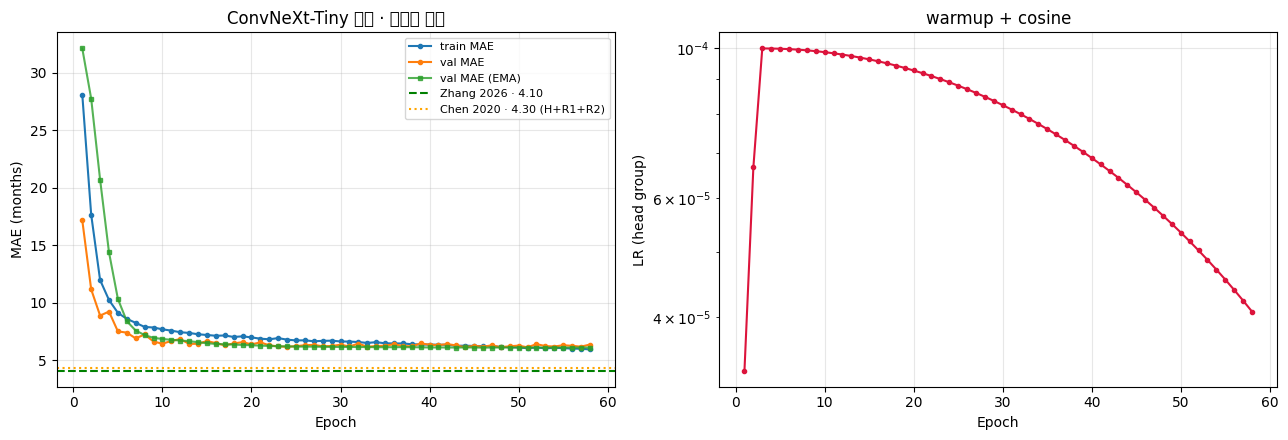

최저 val MAE = 6.12 @ epoch 51


In [16]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
ax[0].plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
if any(v is not None for v in hist.get("val_mae_ema", [])):
    ax[0].plot(ep, hist["val_mae_ema"], "-s", ms=3, alpha=.8, label="val MAE (EMA)")
ax[0].axhline(4.10, ls="--", c="green",  label="Zhang 2026 · 4.10")
ax[0].axhline(4.30, ls=":",  c="orange", label="Chen 2020 · 4.30 (H+R1+R2)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MAE (months)")
ax[0].set_title("ConvNeXt-Tiny 단일 · 전처리 없음"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(ep, hist["lr"], "-o", ms=3, c="crimson")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("LR (head group)")
ax[1].set_title("warmup + cosine"); ax[1].set_yscale("log"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

vm = [v for v in hist["val_mae"] if v is not None]
print(f"최저 val MAE = {min(vm):.2f} @ epoch {int(np.argmin(vm))+1}")

### 4-2. 예측 헬퍼

In [17]:
@torch.no_grad()
def predict_split(model, df, split, bs=16):
    '''개월 단위 (preds, trues, ids) 반환.'''
    loader = DataLoader(BoneAgeDataset(df, split, eval_tf),
                        batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    P, T = [], []
    for x, g, yn, ym in tqdm(loader, desc=f"predict {split}", leave=False):
        x = x.to(device).to(memory_format=torch.channels_last); g = g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = model(x, g)
        P.append(p.float().cpu() * EM_STD + EM_MEAN); T.append(ym.squeeze(1))
    return (torch.cat(P).numpy(), torch.cat(T).numpy(),
            df["id"].astype(str).values)


def report(preds, trues, tag=""):
    mae  = float(np.abs(preds - trues).mean())
    rmse = float(np.sqrt(np.mean((preds - trues) ** 2)))
    bias = float(np.mean(preds - trues))
    print(f"{tag:<28} N={len(trues):>5,}  MAE {mae:5.2f}  RMSE {rmse:5.2f}  bias {bias:+5.2f}")
    return {"N": int(len(trues)), "mae": mae, "rmse": rmse, "bias": bias}


def bootstrap_ci(preds, trues, n_boot=2000, alpha=0.05, seed=SEED):
    '''test 가 200장 수준이라 점추정만으로는 비교가 위험합니다 -> MAE 신뢰구간.'''
    rng = np.random.default_rng(seed)
    n = len(trues)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        boots[b] = np.abs(preds[i] - trues[i]).mean()
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(lo), float(hi)

print("평가 헬퍼 준비 완료")

평가 헬퍼 준비 완료


### 4-3. 검증셋 — 산점도 · 연령대별 MAE

predict val:   0%|          | 0/83 [00:00<?, ?it/s]

VAL                          N=1,324  MAE  6.10  RMSE  8.26  bias -0.09


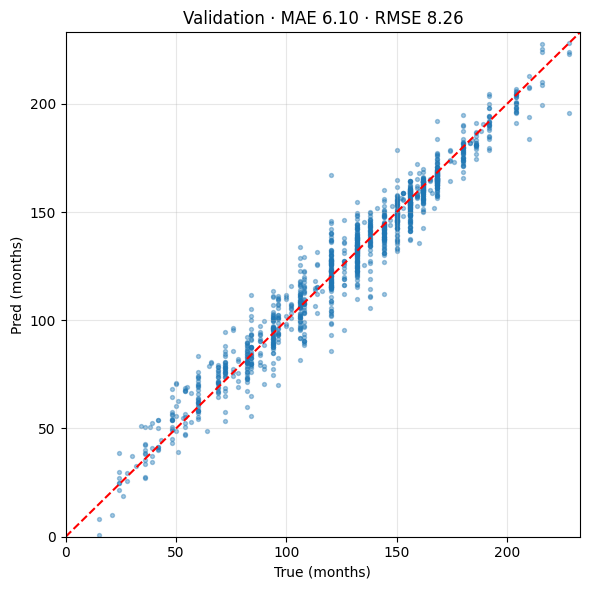

,구간,N,MAE,bias
0,0-4y,38,5.92,1.99
1,4-8y,265,6.79,2.39
2,8-12y,437,7.29,0.84
3,12-16y,526,4.78,-1.93
4,>16y,58,6.04,-2.97


In [18]:
v_pred, v_true, _ = predict_split(eval_model, val_df, "val")
res = {"val": report(v_pred, v_true, "VAL")}

plt.figure(figsize=(6, 6))
plt.scatter(v_true, v_pred, s=8, alpha=.4)
lim = [0, max(v_true.max(), v_pred.max()) + 5]
plt.plot(lim, lim, "r--"); plt.xlim(lim); plt.ylim(lim)
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE {res['val']['mae']:.2f} · RMSE {res['val']['rmse']:.2f}")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

rows = []
for lo, hi, lab in zip([0,48,96,144,192], [48,96,144,192,10**5],
                       ["0-4y","4-8y","8-12y","12-16y",">16y"]):
    m = (v_true >= lo) & (v_true < hi)
    if m.sum():
        rows.append({"구간": lab, "N": int(m.sum()),
                     "MAE": round(float(np.abs(v_pred[m]-v_true[m]).mean()), 2),
                     "bias": round(float(np.mean(v_pred[m]-v_true[m])), 2)})
display(pd.DataFrame(rows))

### 4-4. 최종 테스트셋 — **필터 / 비필터 두 수치 모두**
`EXCLUDE_IDS`를 test에 적용하면 낙관적 편향이 생깁니다.
비교표에 올릴 때는 **어느 쪽 수치인지 반드시 명시**하세요. 테스트가 200장 수준이라 부트스트랩 CI도 같이 냅니다.

In [19]:
assert len(test_df), "test 세트 없음 — 셀 0-3 경로를 확인하세요."

# (a) 현재 설정 그대로 (USE_EXCLUDE 적용 상태)
t_pred, t_true, t_ids = predict_split(eval_model, test_df, "test")
tag_a = "TEST (EXCLUDE 적용)" if USE_EXCLUDE else "TEST (필터 없음)"
res["test_filtered" if USE_EXCLUDE else "test_raw"] = report(t_pred, t_true, tag_a)
lo, hi = bootstrap_ci(t_pred, t_true)
print(f"{'':<28} MAE 95% CI [{lo:.2f}, {hi:.2f}]")

# (b) 필터를 뺀 정직한 수치 (USE_EXCLUDE=True 일 때만 추가 계산)
if USE_EXCLUDE:
    full = load_labels(TEST_CSV)
    idx  = FILE_INDEX["test"]
    full = full[full["id"].isin(idx.keys())].reset_index(drop=True)
    full["path"] = full["id"].map(lambda i: str(idx[i]))
    missing = [i for i in full["id"] if not (CACHE_DIR/"test"/f"{i}.png").exists()]
    if missing:
        print(f"\n[알림] 캐시 없는 test {len(missing)}장 생성 중...")
        for i in missing:
            g = imread_kr(idx[i], cv2.IMREAD_GRAYSCALE)
            if g is not None:
                imwrite_kr(CACHE_DIR/"test"/f"{i}.png", fit_canvas(g)[0])
    f_pred, f_true, _ = predict_split(eval_model, full, "test")
    res["test_raw"] = report(f_pred, f_true, "TEST (필터 없음)")
    lo2, hi2 = bootstrap_ci(f_pred, f_true)
    print(f"{'':<28} MAE 95% CI [{lo2:.2f}, {hi2:.2f}]")
    print(f"\n필터로 인한 MAE 차이 = {res['test_raw']['mae'] - res['test_filtered']['mae']:+.2f} 개월")

res["arch"] = ck["arch"]
res["when"] = time.strftime("%Y-%m-%d %H:%M:%S")
json.dump(res, open(RESULTS_JSON, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print(f"\n결과 저장: {RESULTS_JSON}")

predict test:   0%|          | 0/11 [00:00<?, ?it/s]

TEST (EXCLUDE 적용)            N=  167  MAE  4.63  RMSE  5.85  bias +0.25
                             MAE 95% CI [4.11, 5.19]


predict test:   0%|          | 0/11 [00:00<?, ?it/s]

TEST (필터 없음)                 N=  167  MAE  4.63  RMSE  5.85  bias +0.25
                             MAE 95% CI [4.11, 5.19]

필터로 인한 MAE 차이 = +0.00 개월

결과 저장: C:\Users\Win11Pro\Desktop\checkpoints_convnext_single\results.json


### 4-5. 오차가 큰 상위 케이스 — 라벨 오류·크롭 실패 후보

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053597647.py:10: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053597647.py:10: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053597647.py:10: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053597647.py:10: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053597647.py:10: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_17360\4053

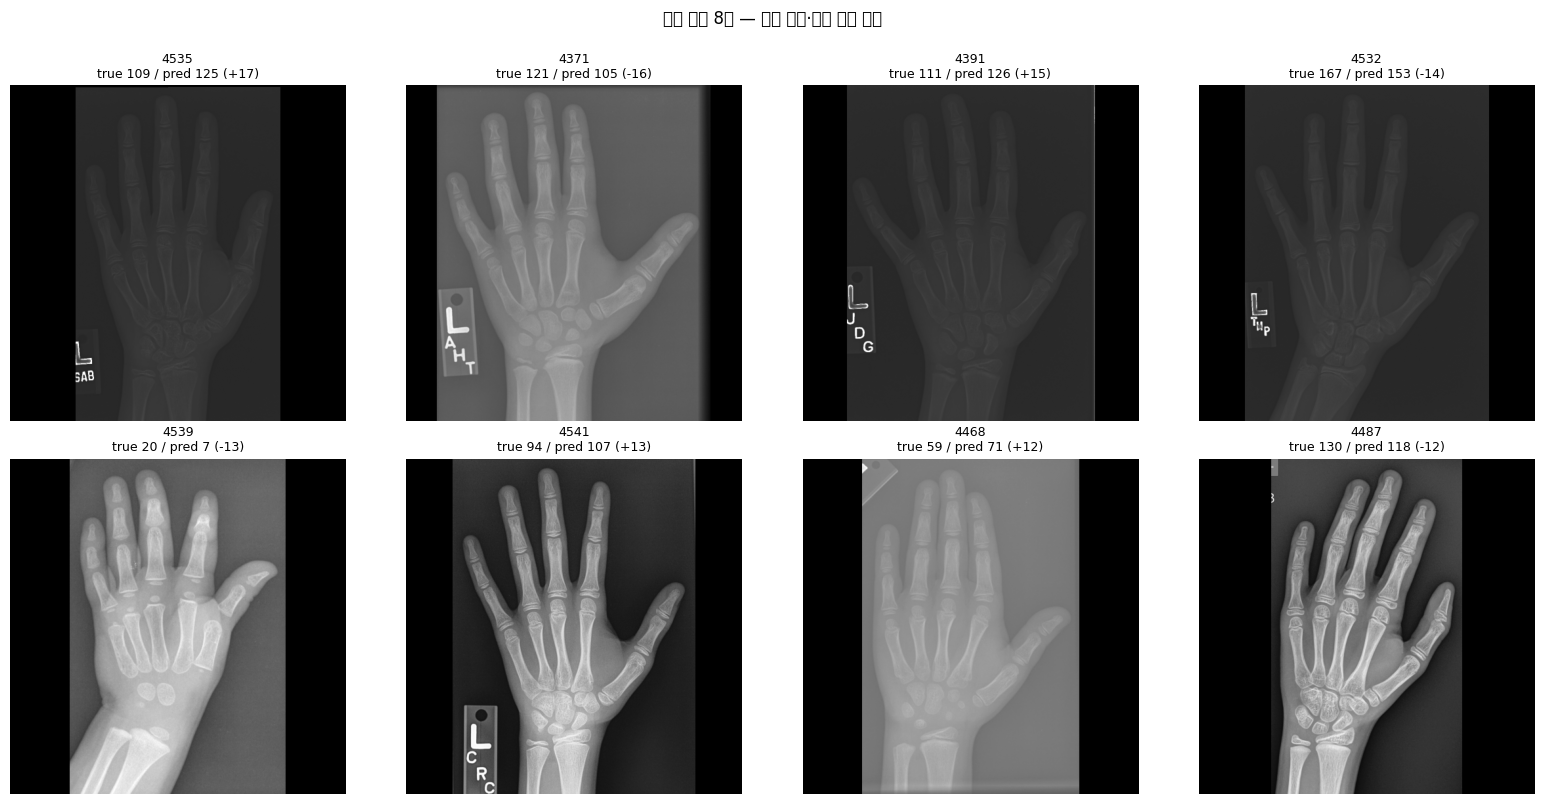

,id,true,pred,err
0,4535,109.0,125.199997,16.6
1,4371,121.0,105.199997,15.5
2,4391,111.0,126.000000,14.6
3,4532,167.0,153.399994,14.0
4,4539,20.0,6.800000,13.0
5,4541,94.0,107.000000,12.9
6,4468,59.0,70.800003,11.9
7,4487,130.0,118.300003,11.9


In [20]:
err = np.abs(t_pred - t_true)
order = np.argsort(-err)[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, i in zip(axes.ravel(), order):
    g = imread_kr(CACHE_DIR / "test" / f"{t_ids[i]}.png", cv2.IMREAD_GRAYSCALE)
    ax.imshow(g, cmap="gray"); ax.axis("off")
    ax.set_title(f"{t_ids[i]}\ntrue {t_true[i]:.0f} / pred {t_pred[i]:.0f} "
                 f"({t_pred[i]-t_true[i]:+.0f})", fontsize=9)
plt.suptitle("오차 상위 8건 — 크롭 실패·라벨 오류 후보", y=1.0)
plt.tight_layout(); plt.show()
display(pd.DataFrame({"id": t_ids[order], "true": t_true[order].round(0),
                      "pred": t_pred[order].round(1), "err": err[order].round(1)}))

### 4-6. Grad-CAM — 모델이 어디를 보는지
크롭만 하고 전처리를 뺐으므로, 관심이 **성장판·수근골**이 아니라 여백·마커로 새는지 확인합니다.
엉뚱한 곳이 밝다면 그것이 곧 전처리(또는 Attention 파이프라인)를 정당화하는 증거입니다.

[Grad-CAM] target = stages.3


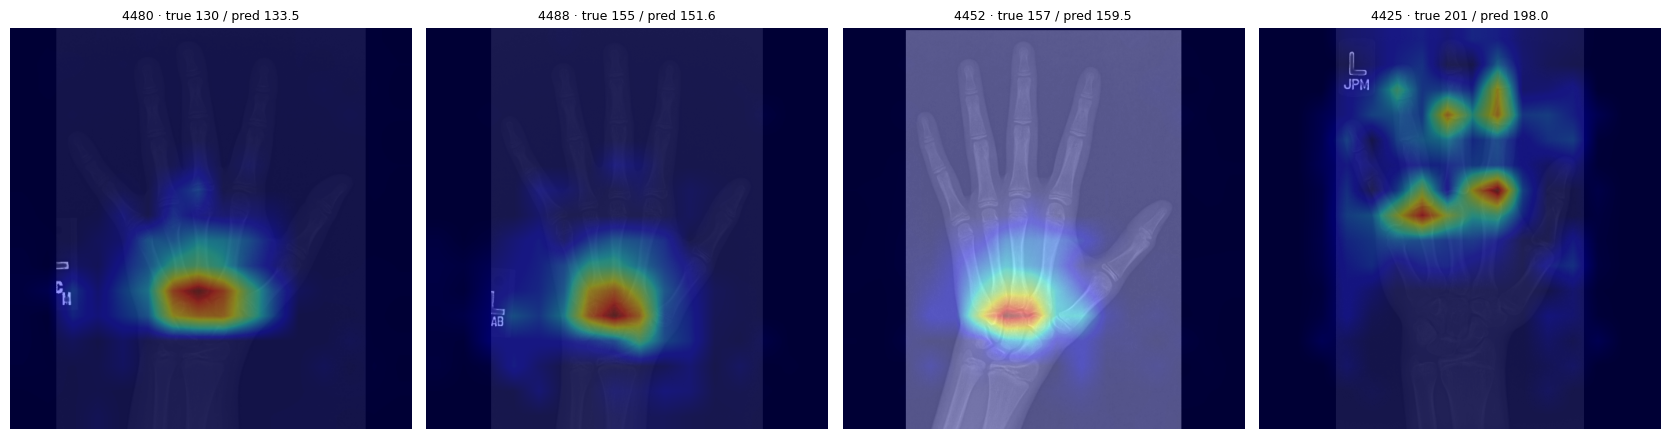

In [21]:
class GradCAM:
    '''ConvNeXt 마지막 stage 특징맵 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt, name = self._pick(model.backbone)
        print(f"[Grad-CAM] target = {name}")
        tgt.register_forward_hook(lambda m, i, o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m, gi, go: setattr(self, "grad", go[0].detach()))

    @staticmethod
    def _pick(backbone):
        mods = dict(backbone.named_modules())
        for n in ("stages.3", "stages_3", "norm_pre", "stages"):
            if n in mods:
                return mods[n], n
        return backbone, "backbone(output)"

    def __call__(self, x, g):
        self.model.eval(); self.model.zero_grad()
        out = self.model(x, g); out.sum().backward()
        w   = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.feat).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].cpu().numpy()
        return cam / (cam.max() + 1e-8), float(out.item()) * EM_STD + EM_MEAN


cam_engine = GradCAM(eval_model)
samp = test_df.sample(min(4, len(test_df)), random_state=SEED)
fig, axes = plt.subplots(1, len(samp), figsize=(4.2 * len(samp), 4.6))
axes = np.atleast_1d(axes)
for ax, (_, r) in zip(axes, samp.iterrows()):
    g8 = imread_kr(CACHE_DIR / "test" / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x  = eval_tf(np.stack([g8] * 3, -1)).unsqueeze(0).to(device).to(memory_format=torch.channels_last)
    gd = torch.tensor([[float(r["male"])]], device=device)
    cam, pred = cam_engine(x, gd)
    ax.imshow(g8, cmap="gray"); ax.imshow(cam, cmap="jet", alpha=.42)
    ax.set_title(f"{r['id']} · true {r['boneage']:.0f} / pred {pred:.1f}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

### 4-7. 단일 이미지 추론 (완전 독립)
이미지 준비 설정을 **체크포인트에서 읽어** 학습 때와 동일한 처리를 보장합니다.
입력은 **YOLO로 손이 이미 크롭된 이미지**입니다.

In [22]:
_INFER_CACHE = {}

def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    '''크롭된 X-ray 경로 + 성별(True=남) -> 골연령(개월).'''
    key = str(ckpt_path)
    if key not in _INFER_CACHE:
        c = torch_load(ckpt_path, map_location=device)
        m = build_model(c["arch"], pretrained=False)
        m.load_state_dict(c["model"]); m.eval()
        _INFER_CACHE[key] = (m, c)
    m, c = _INFER_CACHE[key]
    a = c["arch"]

    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(image_path)
    canvas, _ = fit_canvas(g, size=a["IMG_SIZE"], mode=a.get("RESIZE_MODE", "letterbox"),
                          pad_val=a.get("PAD_VALUE", 0), anchor=a.get("PAD_ANCHOR", "center"))
    x  = eval_tf(np.stack([canvas] * 3, -1)).unsqueeze(0).to(device).to(memory_format=torch.channels_last)
    gd = torch.tensor([[1.0 if is_male else 0.0]], device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        p = m(x, gd)
    months = float(p.float().cpu().item()) * c["age_std"] + c["age_mean"]
    return months


# 사용 예 (test 첫 장)
_r = test_df.iloc[0]
_m = predict_bone_age(_r["path"], bool(_r["male"]))
print(f"[{_r['id']}] 예측 {_m:.1f}개월 ({_m/12:.1f}세) · 실제 {_r['boneage']:.0f}개월")

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.1)
[head] 특징맵 (768, 16, 16) · head_type=gap
[4360] 예측 173.1개월 (14.4세) · 실제 169개월


---
## 부록 · 성능이 기대에 못 미칠 때 만지는 순서

| 순위 | 조정 | 값 | 기대 효과 |
|---|---|---|---|
| 1 | `LR_BACKBONE` | 1e-5 → 2e-5 | 언더피팅(train MAE도 높음)일 때 |
| 2 | `DROP_PATH` | 0.1 → 0.2 | 과적합(train≪val)일 때 |
| 3 | `EPOCHS` | 60 → 100 | cosine이 덜 수렴한 곡선이면 |
| 4 | `HEAD_TYPE` | `"gap"` → `"paper"` | Xception 노트북과 헤드 조건을 맞출 때 |
| 5 | `ACCUM_STEPS` | 4 → 8 (유효 64) | val 곡선이 톱니처럼 흔들릴 때 |
| 6 | `BACKBONE` | `_384` → `in12k_ft_in1k` | 서로 다른 사전학습 소스 비교 |
| 7 | `HUBER_BETA` | 0.5 → 1.0 | bias가 한쪽으로 치우칠 때 |

**한 번에 하나씩만 바꾸세요.** 이 노트북은 캐시가 `PRE_TAG`로 분리되지만
하이퍼파라미터는 `CKPT_DIR` 하나를 공유합니다 — 여러 설정을 병렬로 돌릴 거라면
`CKPT_DIR` 이름에 태그를 붙여 분리하세요.

## 비교 기준선

| 실험 | 전처리 | 구조 | 위치 |
|---|---|---|---|
| Xception+TopHat+CLAHE | 5단계 | 단일 회귀 | 기존 노트북 |
| v8 | CLAHE + 패딩 추정 | Attention+LDL | `checkpoints_attention_v8` |
| v10 | 없음 | Attention+LDL | `checkpoints_attention_v10` |
| **이 노트북** | **없음** | **단일 회귀** | `checkpoints_convnext_single` |

v10과 이 노트북의 차이 = **Attention+LDL의 순수 기여도**
v8과 v10의 차이 = **전처리의 순수 기여도**
네 칸이 채워지면 2×2 ablation 표가 완성됩니다.